In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import seaborn as sns
from binance_data_loader import BinanceDataLoader
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.ar_model import AutoReg
import cvxpy as cvx



In [30]:
data_loader = BinanceDataLoader(
    data_directory="/Users/chinjieheng/Documents/data/binance_dailydata",
    funding_rate_directory="/Users/chinjieheng/Documents/data/binance_fundingrate_data",  # Add this line
    min_records=60,
    min_volume=1e5,
    start_date="2024-01-01",
    end_date=None
)
price_df = data_loader.get_price_matrix()            # index: daily timestamps
returns_df = data_loader.get_returns_matrix()        # index: daily timestamps
funding_long = data_loader.get_funding_long_form()   # MultiIndex (symbol, timestamp) with rate + interval
#funding_long = funding_long[funding_long['fundingIntervalHours'] != 8]
#funding_long = funding_long[funding_long['fundingIntervalHours'] != 1]  # drop any 1h intervals per symbol/timestamp
  # drop any 1h intervals per symbol/timestamp
funding_df = (
    funding_long['fundingRate']
    .unstack(level=0)
    .sort_index()
)   # index: funding event timestamps (full timestamps), columns: symbols

Loading Binance data from /Users/chinjieheng/Documents/data/binance_dailydata (timeframe=1d)...
Found 606 USDT trading pairs
Using a 30-bar rolling window for 30d volume checks
✓ BTCUSDT loaded successfully with 721 records, avg volume: 17,420,296,024
Loaded 570 cryptocurrencies
Filtered 33 cryptocurrencies (insufficient data/volume)
Precomputing returns matrix (FAST numpy version)...
Building returns matrix for 570 tickers over 721 dates...
Precomputed returns matrix shape: (721, 570)
Date range: 2024-01-01 00:00:00 to 2025-12-21 00:00:00
Loading funding rate data from /Users/chinjieheng/Documents/data/binance_fundingrate_data...
Found 608 funding rate files
Loaded funding rates for 570 symbols


Total internal gaps found across all symbols: 19829
Number of symbols with gaps: 86


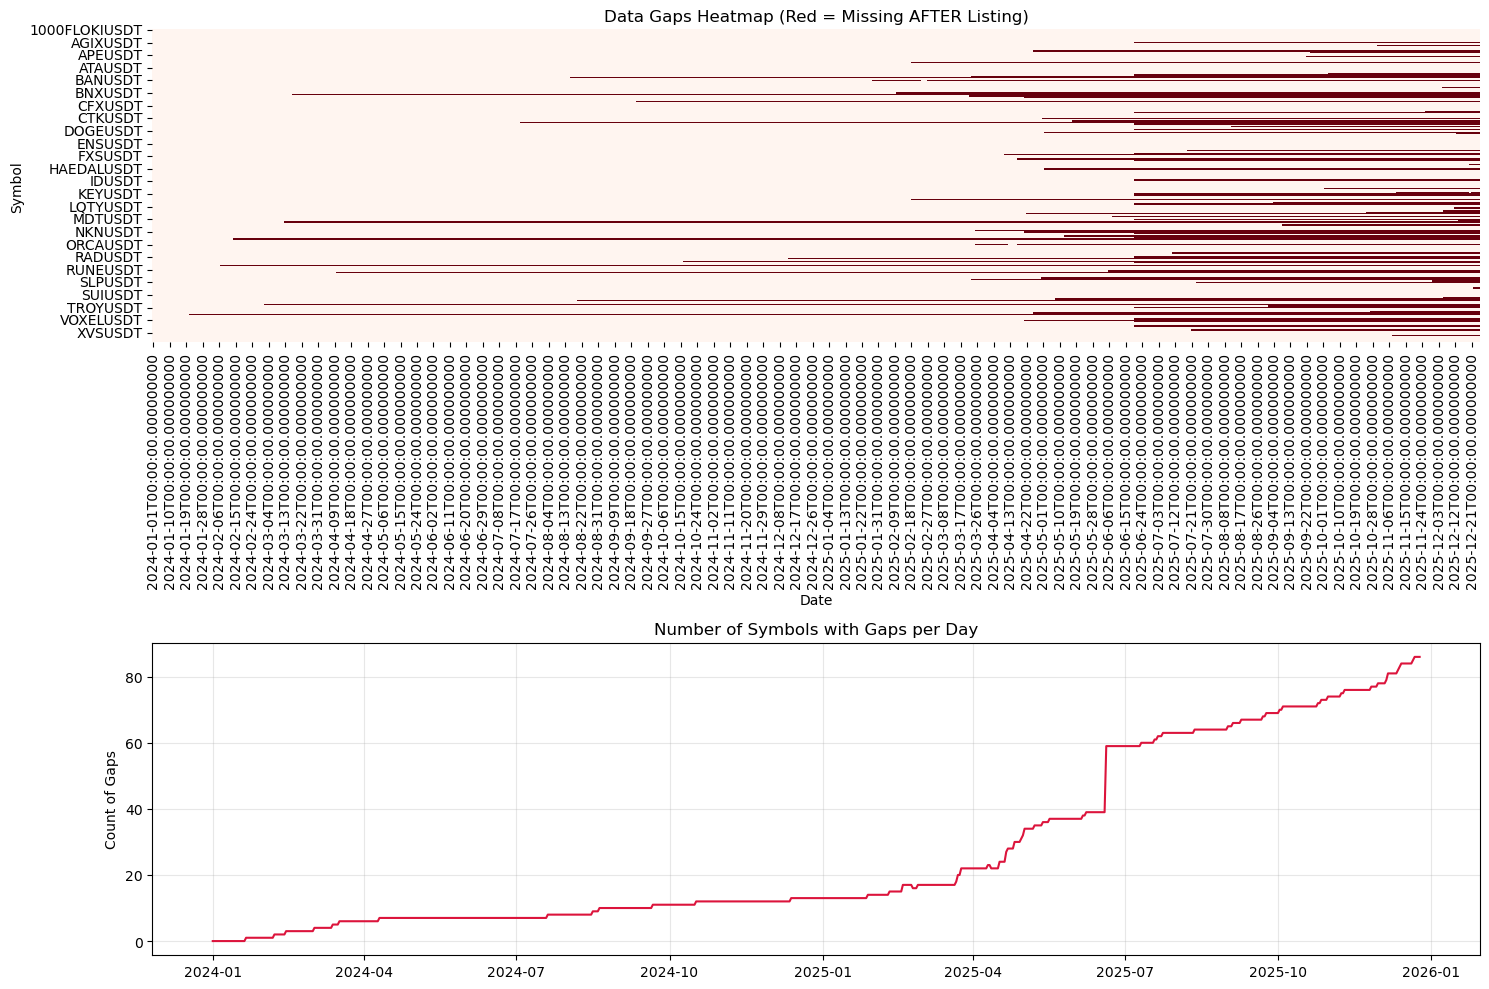


Top 10 Symbols with most internal gaps:
symbol
UMAUSDT       705
RONINUSDT     688
OMUSDT        681
TONUSDT       664
METISUSDT     653
BOMEUSDT      649
SAGAUSDT      625
CVXUSDT       524
BANANAUSDT    497
SYSUSDT       493
dtype: int64


In [31]:
# --- Data Missingness Analysis (Focus on Gaps) ---

# Create a mask for "active" regions (after the first valid observation for each symbol)
# cumsum() of boolean treats True as 1, so once it hits a valid value, it becomes > 0 forever.
is_active = daily_funding.notna().cumsum() > 0

# Identify gaps: It must be active (after listing) AND it must be null
gap_mask = is_active & daily_funding.isnull()

# 1. Calculate gaps per symbol
gaps_per_symbol = gap_mask.sum()
total_gaps = gaps_per_symbol.sum()
symbols_with_gaps = gaps_per_symbol[gaps_per_symbol > 0]

print(f"Total internal gaps found across all symbols: {total_gaps}")
print(f"Number of symbols with gaps: {len(symbols_with_gaps)}")

# 2. Visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Heatmap of GAPS ONLY
# We transpose so X-axis is time
sns.heatmap(gap_mask.T, cbar=False, cmap='Reds', ax=axes[0]) 
axes[0].set_title("Data Gaps Heatmap (Red = Missing AFTER Listing)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Symbol")

# Gaps over time
gaps_per_day = gap_mask.sum(axis=1)
axes[1].plot(gaps_per_day.index, gaps_per_day.values, color='crimson')
axes[1].set_title("Number of Symbols with Gaps per Day")
axes[1].set_ylabel("Count of Gaps")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# List top 10 symbols with most gaps
print("\nTop 10 Symbols with most internal gaps:")
print(symbols_with_gaps.sort_values(ascending=False).head(10))

In [32]:
IN_SAMPLE_START_DATE = "2024-01-01"
IN_SAMPLE_END_DATE = "2024-12-31"

In [33]:
def robust_ar_1_fit(funding_rates):
    """Robust AR(1) fitting with fallback to manual estimation,
    Assure input to AR fit does not contain inf/nan prevents Runtime error"""

    if len(funding_rates) < 30:
        return None
    
    #Will Still warn if contain nan, so check again explicitly
    if not np.all(np.isfinite(funding_rates)):
        raise ValueError("Input returns to AutoReg contain non-finite values!")
    
    model = AutoReg(funding_rates, lags=1, old_names=False).fit()
    if hasattr(model, 'params') and len(model.params) == 2: #AR(1) + constant
        return model
    
def calculate_ar1_factor_custom_dates(symbols, current_day):
    """Calculate AR(1)  factor for a specific coin using custom start and 30 day lookback
    Extra nan/inf handling for all returns, prevents warnings downsstream"""

    print(f"Calculating AR(1) factor for {symbols} on {current_day}")

    if isinstance(current_day, str):
        current_day = pd.to_datetime(current_day)

    train_start =  pd.to_datetime(IN_SAMPLE_START_DATE)
    if (current_day - train_start) < pd.Timedelta(days=30):
        print("Error: current day must be at least 30 days after train start date for lookback")
        return {}
    
    ar1_results = {}
    relevant_funding_rate = daily_funding[(daily_funding.index > current_day - pd.Timedelta(days=30)) & 
                                            (daily_funding.index <= current_day)].sort_index().reset_index(drop=True)
    for symbol in symbols:
        symbol_rates = relevant_funding_rate[symbol].copy()

        if symbol_rates.empty or len(symbol_rates) < 30:
            ar1_results[symbol] = np.nan
            continue

        funding_rate = symbol_rates.values

        #Remove nan/inf BEFORE  len check
        funding_rate = funding_rate[np.isfinite(funding_rate)]

        if len(funding_rate) < 30:
            ar1_results[symbol] = np.nan
            continue

        #Check for all zero
        if np.std(funding_rate) < 1e-10:
            ar1_results[symbol] = np.nan
            continue

        #Final inf/nan check
        if not np.all(np.isfinite(funding_rate)):
            ar1_results[symbol] = np.nan
            continue

        ar1_model = robust_ar_1_fit(funding_rate)

        if ar1_model is not None:
            ar1_results[symbol] = {
                'intercept':ar1_model.params[0],
                'ar1_factor':ar1_model.params[1]
            }

    return ar1_results

In [34]:
ar1_factors_list = []
for days in daily_funding.index:
    ar1_results_for_day =  calculate_ar1_factor_custom_dates(daily_funding.columns, days)
    if ar1_results_for_day:
        for symbol, res in ar1_results_for_day.items():
            if isinstance(res, dict) and ('ar1_factor' in res) and ('intercept' in res):
                day_df = pd.DataFrame([{                    
                    'symbol': symbol,
                    'intercept': res['intercept'],
                    'ar1_factor': res['ar1_factor'],
                    'date': days,
                }])
                ar1_factors_list.append(day_df)

if ar1_factors_list:
    ar1_factors = pd.concat(ar1_factors_list, ignore_index=True)
else:
    ar1_factors = pd.DataFrame()

#ar1_factors.to_csv("ar1_factors_daily.csv", index=False)
ar1_factors

Calculating AR(1) factor for Index(['1000FLOKIUSDT', '1000LUNCUSDT', '1000PEPEUSDT', '1000SHIBUSDT',
       '1000XECUSDT', '1INCHUSDT', 'AAVEUSDT', 'ACHUSDT', 'ADAUSDT',
       'AGIXUSDT',
       ...
       'XRPUSDT', 'XTZUSDT', 'XVGUSDT', 'XVSUSDT', 'YFIUSDT', 'ZBTUSDT',
       'ZECUSDT', 'ZENUSDT', 'ZILUSDT', 'ZRXUSDT'],
      dtype='object', name='symbol', length=223) on 2024-01-01 00:00:00
Error: current day must be at least 30 days after train start date for lookback
Calculating AR(1) factor for Index(['1000FLOKIUSDT', '1000LUNCUSDT', '1000PEPEUSDT', '1000SHIBUSDT',
       '1000XECUSDT', '1INCHUSDT', 'AAVEUSDT', 'ACHUSDT', 'ADAUSDT',
       'AGIXUSDT',
       ...
       'XRPUSDT', 'XTZUSDT', 'XVGUSDT', 'XVSUSDT', 'YFIUSDT', 'ZBTUSDT',
       'ZECUSDT', 'ZENUSDT', 'ZILUSDT', 'ZRXUSDT'],
      dtype='object', name='symbol', length=223) on 2024-01-02 00:00:00
Error: current day must be at least 30 days after train start date for lookback
Calculating AR(1) factor for Index(['1000FLOKI

,symbol,intercept,ar1_factor,date
0,1000FLOKIUSDT,0.000125,0.328451,2024-01-31
1,1000LUNCUSDT,0.000173,0.274511,2024-01-31
2,1000PEPEUSDT,0.000166,0.400282,2024-01-31
3,1000SHIBUSDT,0.000179,0.305534,2024-01-31
4,1000XECUSDT,-0.001055,0.065859,2024-01-31
...,...,...,...,...
108361,YFIUSDT,0.000066,-0.102447,2025-12-25
108362,ZECUSDT,-0.000029,0.444001,2025-12-25
108363,ZENUSDT,-0.000013,0.314858,2025-12-25
108364,ZILUSDT,0.000111,0.241957,2025-12-25


In [35]:
# Melt daily_funding to long format to merge with ar1_factors
daily_funding_long = daily_funding.stack().reset_index()
daily_funding_long.columns = ['date', 'symbol', 'funding_rate']

# Merge ar1_factors with current day's funding rate
funding_rate_forecast = pd.merge(
    ar1_factors,
    daily_funding_long,
    on=['date', 'symbol'],
    how='inner'
)

# Calculate predicted funding rate for the NEXT day (t+1) using model fit on data up to t
# y_{t+1} = alpha + beta * y_t
funding_rate_forecast['predicted_funding_rate'] = (
    funding_rate_forecast['intercept'] + 
    funding_rate_forecast['ar1_factor'] * funding_rate_forecast['funding_rate']
)

funding_rate_forecast = funding_rate_forecast.drop(columns=['intercept', 'ar1_factor'])
funding_rate_forecast

,symbol,date,funding_rate,predicted_funding_rate
0,1000FLOKIUSDT,2024-01-31,0.000300,0.000224
1,1000LUNCUSDT,2024-01-31,0.000300,0.000256
2,1000PEPEUSDT,2024-01-31,0.000188,0.000241
3,1000SHIBUSDT,2024-01-31,0.000300,0.000271
4,1000XECUSDT,2024-01-31,-0.000496,-0.001087
...,...,...,...,...
108361,YFIUSDT,2025-12-25,0.000091,0.000057
108362,ZECUSDT,2025-12-25,0.000100,0.000015
108363,ZENUSDT,2025-12-25,0.000100,0.000019
108364,ZILUSDT,2025-12-25,0.000100,0.000135


Portfolio selections saved to 'daily_portfolio_selections.csv'


/var/folders/4j/50_b76mn3qj360c47nzkyxdc0000gn/T/ipykernel_45569/1836624847.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  target_portfolio = funding_rate_forecast.groupby('date', group_keys=False).apply(filter_top_bottom)


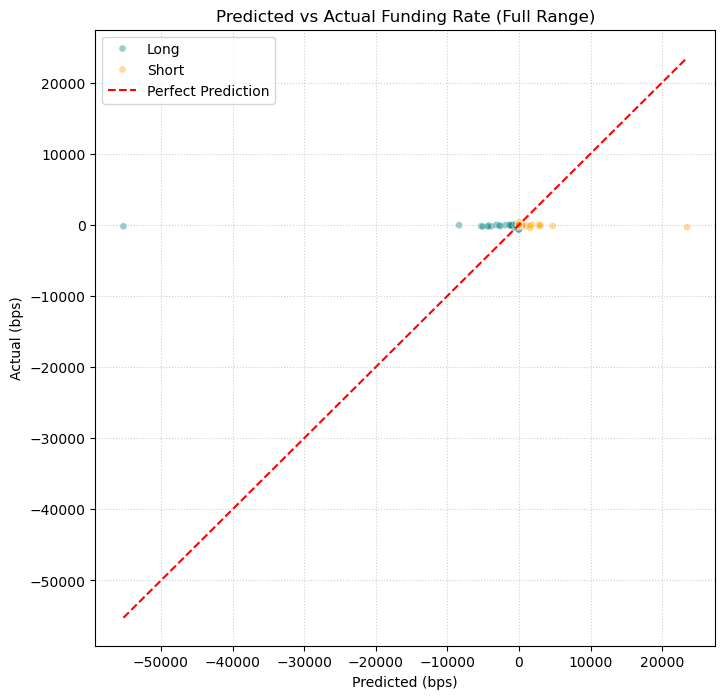

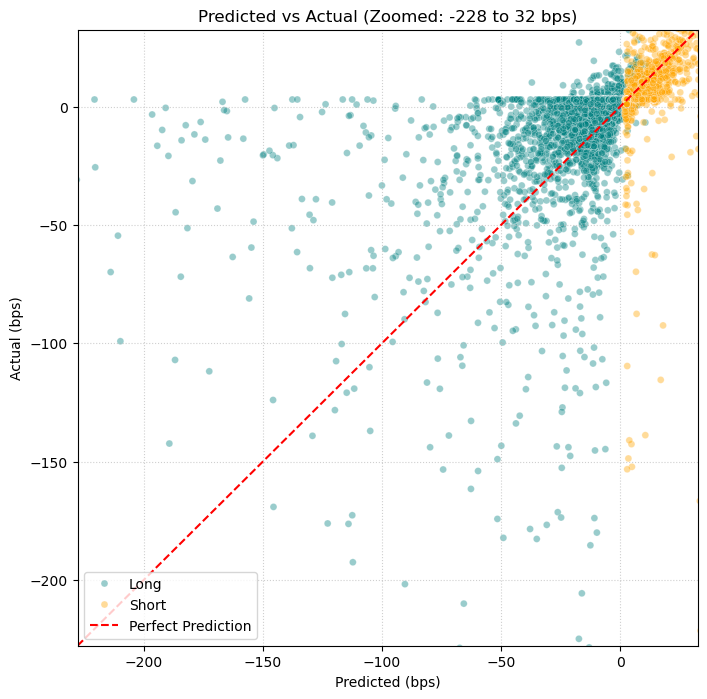

In [36]:
# 1. Prepare true t+1 funding rates
true_next_funding = daily_funding.shift(-1).stack().reset_index()
true_next_funding.columns = ['date', 'symbol', 'true_next_funding_rate']

# 2. Filter Forecasts to Top/Bottom 10 per day *before* merging with actuals
# This ensures we evaluate the specific assets the strategy would have selected,
# rather than selecting from the subset of assets that happen to have data the next day.
def filter_top_bottom(group, n=5):
    if len(group) <= 2*n:
        group = group.copy()
        group['side'] = 'All'
        return group
        
    top = group.nlargest(n, 'predicted_funding_rate').copy()
    top['side'] = 'Short' # High funding -> Short to receive
    
    bottom = group.nsmallest(n, 'predicted_funding_rate').copy()
    bottom['side'] = 'Long' # Low funding -> Long
    
    return pd.concat([top, bottom]).drop_duplicates()

target_portfolio = funding_rate_forecast.groupby('date', group_keys=False).apply(filter_top_bottom)

# --- Record the selections ---
target_portfolio.sort_values(['date', 'side', 'predicted_funding_rate'], inplace=True)
target_portfolio.to_csv("daily_portfolio_selections.csv", index=False)
print("Portfolio selections saved to 'daily_portfolio_selections.csv'")

# 3. Merge with true values
evaluation_df = pd.merge(
    target_portfolio,
    true_next_funding,
    on=['date', 'symbol'],
    how='inner'
).dropna()

# 4. Visualization (Converted to Basis Points for precision)
# 1 bp = 0.0001 (0.01%)
eval_bps = evaluation_df.copy()
eval_bps['predicted_bps'] = eval_bps['predicted_funding_rate'] * 10000
eval_bps['true_bps'] = eval_bps['true_next_funding_rate'] * 10000

# --- Plot 1: Full Range ---
plt.figure(figsize=(8, 8))
sns.scatterplot(data=eval_bps, x='predicted_bps', y='true_bps', hue='side', alpha=0.4, palette={'Long': 'teal', 'Short': 'orange', 'All': 'grey'}, s=25)

min_val = min(eval_bps['predicted_bps'].min(), eval_bps['true_bps'].min())
max_val = max(eval_bps['predicted_bps'].max(), eval_bps['true_bps'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Perfect Prediction')

plt.title("Predicted vs Actual Funding Rate (Full Range)")
plt.xlabel("Predicted (bps)")
plt.ylabel("Actual (bps)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- Plot 2: Zoomed (1st to 99th Percentile) ---
plt.figure(figsize=(8, 8))

# Determine zoom limits
all_values = pd.concat([eval_bps['predicted_bps'], eval_bps['true_bps']])
lower_lim = all_values.quantile(0.01)
upper_lim = all_values.quantile(0.99)

sns.scatterplot(data=eval_bps, x='predicted_bps', y='true_bps', hue='side', alpha=0.4, palette={'Long': 'teal', 'Short': 'orange', 'All': 'grey'}, s=25)

plt.plot([lower_lim, upper_lim], [lower_lim, upper_lim], 'r--', lw=1.5, label='Perfect Prediction')

plt.xlim(lower_lim, upper_lim)
plt.ylim(lower_lim, upper_lim)

plt.title(f"Predicted vs Actual (Zoomed: {lower_lim:.0f} to {upper_lim:.0f} bps)")
plt.xlabel("Predicted (bps)")
plt.ylabel("Actual (bps)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()